In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os

In [2]:
#Semiconductor Dimensions
width = 10.0/100
length = 10.0/100
thickness = 1.25/1000
cross_area = width * thickness
q = 1.602e-19

In [3]:
def analyze_hall_file(file_path_or_df, I, label="", 

    T = "Temperature (K)",
    B_gauss = "B-Field (Gauss)",
    curr_AB = "sample I AB", 
    curr_nAB = "sample I -AB", 
                      
    #longitudinal voltages
    V_DC = "Voltage DC",
    V_nDC = "Voltage -DC",
    
    #transverse voltages
    V_AC = "Voltage AC",
    V_nAC = "Voltage -AC",
    V_BD = "Voltage BD",
    V_nBD = "Voltage -BD",
    assume_whitespace_if_not_csv=True,
    zero_field_gauss=0.0,
    plot=True,
    make_subplots=True,
    thr=200.0
):

    # --- load ---
    if hasattr(file_path_or_df, "to_csv") and hasattr(file_path_or_df, "columns"):
        df = file_path_or_df.copy()
        src_label = label or "in-memory DataFrame"  
    elif isinstance(file_path_or_df, (str, bytes, os.PathLike, Path)):
        fp = Path(file_path_or_df)
        if fp.suffix.lower() == ".csv":
            df = pd.read_csv(fp)
        else: 
            df = pd.read_csv(fp, sep=r"\s*\t\s*", engine="python")
        src_label = label or fp.name
    else: 
        raise TypeError("error")
    
    # --- numeric conversion ---
    cols_to_convert = [T, B_gauss, curr_AB, curr_nAB, V_DC, V_nDC]
    cols_to_convert += [V_AC, V_nAC]
    for c in cols_to_convert:
        if c not in df.columns:
            raise KeyError(f"Required column missing: {c}")
        df[c] = pd.to_numeric(df[c], errors="coerce")
        
    # --- BD if it exists ---
    has_bd = (V_BD in df.columns) and (V_nBD in df.columns)
    if has_bd:
        df[V_BD] = pd.to_numeric(df[V_BD], errors="coerce")
        df[V_nBD] = pd.to_numeric(df[V_nBD], errors="coerce")
    else:
        print("using AC only for Hall")

    df = df.dropna(subset=[T, B_gauss, curr_AB, curr_nAB, V_DC, V_nDC, V_AC, V_nAC]).copy()
    df = df.sort_values(T).reset_index(drop=True)
    
#----------------------------------------------------------------------------------------------------------------#

    df["B"] = df[B_gauss]/1e4
    #df["I"] = 0.5*(df[curr_AB].abs() + df[curr_nAB].abs())
    df["inv_T"] = 1.0/df[T]
    
    # --- voltage asymmetries ---
    df["Vxx"] = 0.5*(df[V_DC]+df[V_nDC])
    Vxy_AC = 0.5*(df[V_AC]-df[V_nAC])
    if has_bd:
        Vxy_BD = 0.5*(df[V_BD]-df[V_nBD])
        df["Vxy"] = 0.5*(Vxy_AC + Vxy_BD)
        df["Vxy_AC"] = Vxy_AC
        df["Vxy_BD"] = Vxy_BD
    else:
        df["Vxy"] = Vxy_AC
        df["Vxy_AC"] = Vxy_AC
    
    # --- resistances ---
    df["Rxx"] = df["Vxx"]/I
    df["Rxy"] = df["Vxy"]/I
    df["rhoxx"] = df["Rxx"] * (cross_area / length)
    #df["rhoxx"] = df["rhoxx"].abs()
    df["rhoxy"] = df["Rxy"] * thickness
    df["sigma"] = 1.0/df["rhoxx"]
    
    # --- hall coefficient ---
    with np.errstate(divide="ignore", invalid="ignore"):
        df["hall_coeff"] = df["rhoxy"]/df["B"]
        df["n"] = 1.0/(q*df["hall_coeff"])
        df["mu"] = df["sigma"]*df["hall_coeff"]
        df["hallxsigma"] = df["hall_coeff"]*df["sigma"]
    
    # --- MR relative to B=0 (if B=0 rows exist in same file) ---
    zero_mask = np.abs(df[B_gauss] - zero_field_gauss) < 50  # treat |B|<50 G as "zero"
    df0 = df[zero_mask]
    rho0 = np.nan
    if not df0.empty:
        rho0 = float(df0["rhoxx"].median())
        df["MR_fraction"] = (df["rhoxx"] - rho0) / rho0

        
    # --- plots ---
    if plot and make_subplots:
        B = df[B_gauss].to_numpy()
        neg  = df[B <  -thr].copy()
        zero = df[(B >= -thr) & (B <= thr)].copy()
        pos  = df[B >   thr].copy()
        
        panels = [
            (neg,  f"Negative B Field"),
            (zero, f"(Near) Zero B Field"),
            (pos,  f"Positive B Field"),
        ]
        
        def row(figtitle, xcol, ycol, xlabel, ylabel, invert_x=False):
            fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
            for ax, (subdf, title) in zip(axes, panels):
                if (xcol not in subdf.columns) or (ycol not in subdf.columns):
                    ax.set_title(title + " (n=0)")
                    ax.grid(True, alpha=0.3)
                    continue
                x = pd.to_numeric(subdf[xcol], errors="coerce").to_numpy()
                y = pd.to_numeric(subdf[ycol], errors="coerce").to_numpy()
                m = np.isfinite(x) & np.isfinite(y)
                ax.plot(x[m], y[m], ".", ms=3)
                ax.set_title(f"{title}")
                ax.set_xlabel(xlabel)
                if invert_x:
                    ax.invert_xaxis()
                if "Resistivity" in ylabel:
                    ax.set_ylim(-0.01, 0.01)
                if "Conductivity" in ylabel:
                    ax.set_ylim(-2000, 4000)
            axes[0].set_ylabel(ylabel)
            fig.suptitle(f"{src_label} — {figtitle}")
            fig.tight_layout(rect=(0,0,1,0.94))
            plt.show()

        # ρ, σ, R_H vs 1/T (invert x)
        row("ρ vs 1/T",   "inv_T", "rhoxx",      "1 / T (1/K)", "Resistivity ρ (Ω·m)",    invert_x=True)
        row("σ vs 1/T",   "inv_T", "sigma",      "1 / T (1/K)", "Conductivity σ (S/m)",   invert_x=True)
        row("R_H vs 1/T", "inv_T", "hall_coeff", "1 / T (1/K)", "Hall coefficient R_H",   invert_x=True)

        # μ, n, R_H×σ vs T
        row("Mobility vs T",         T, "mu",         "Temperature (K)", "Mobility μ (m²/V·s)")
        row("Carrier concentration", T, "n",          "Temperature (K)", "n (m⁻³)")
        row("R_H × σ vs T",          T, "hallxsigma", "Temperature (K)", "R_H × σ")

        # Vxy vs B
        #row("Hall antisymmetric V vs B", "B", "Vxy", "B (T)", "Vxy (V)")
            
    return df, rt_summary

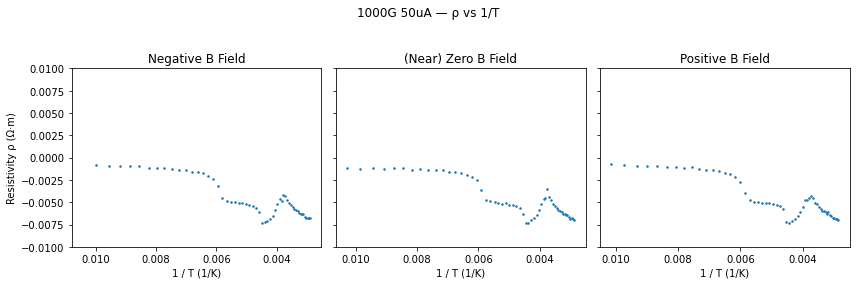

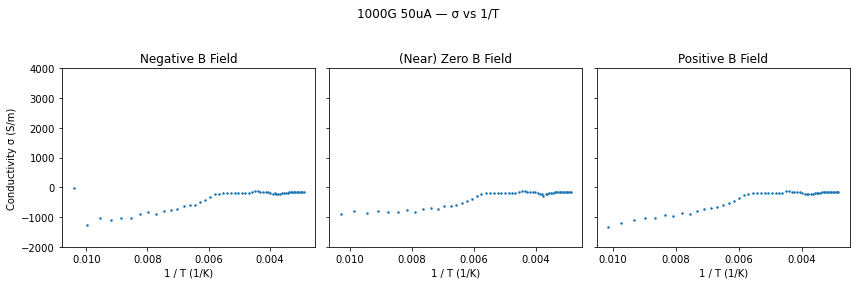

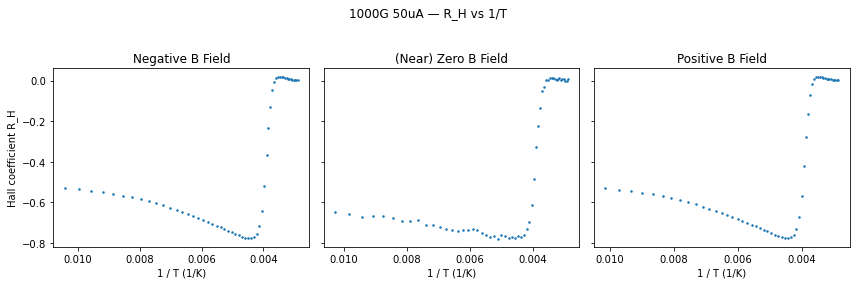

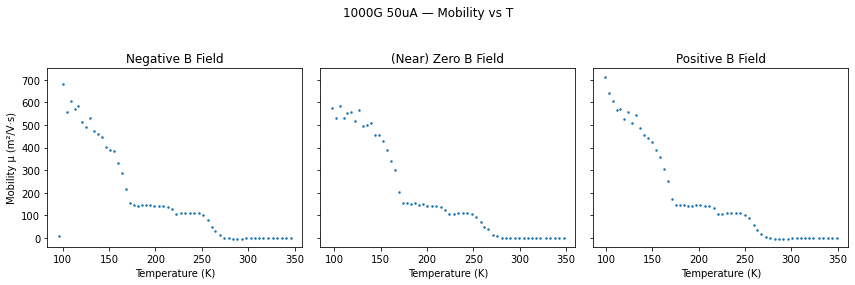

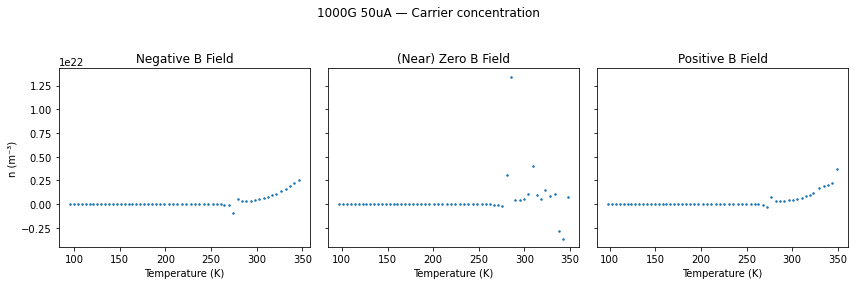

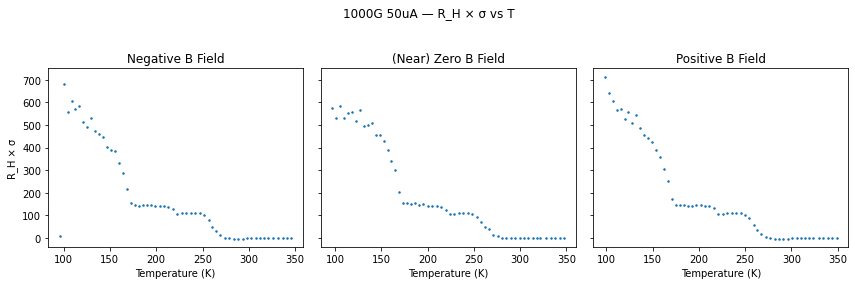

In [4]:
df_1000G50, rt_1000G50 = analyze_hall_file("1000G50uA.txt", I = 50e-6, plot=False);
analyze_hall_file(df_1000G50, I = 50e-6, label="1000G 50uA", plot=True, make_subplots=True);

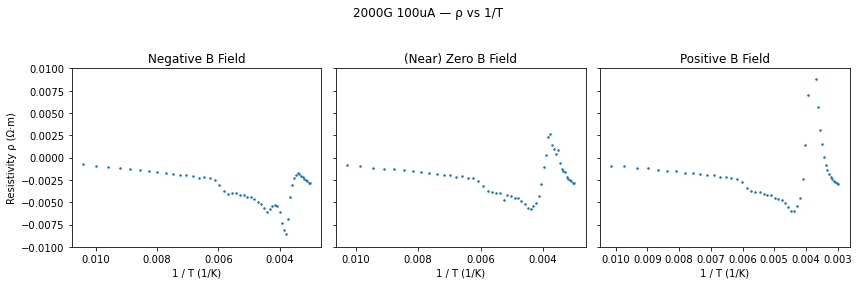

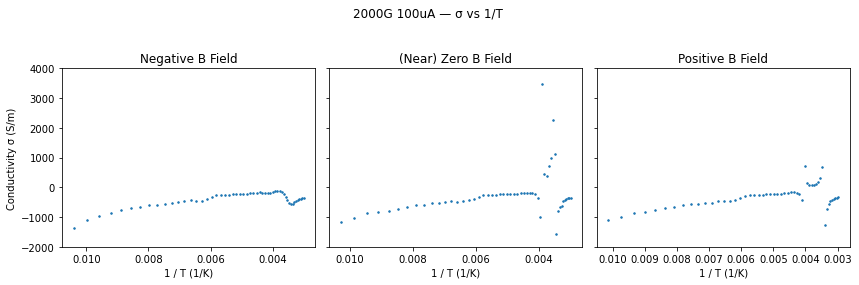

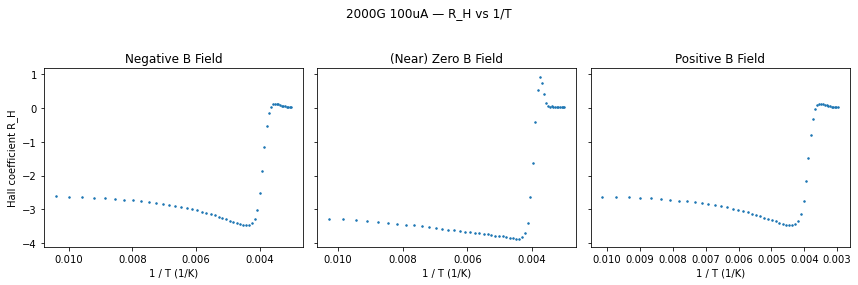

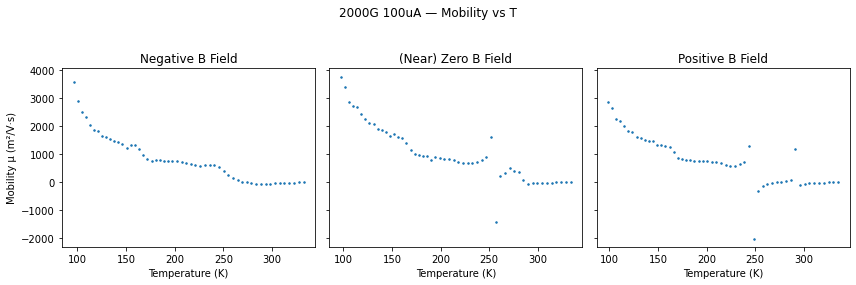

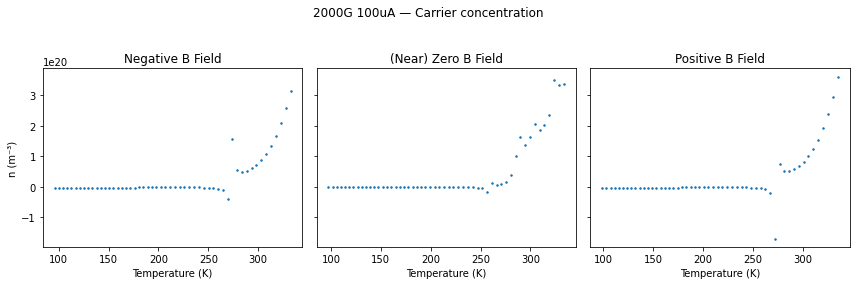

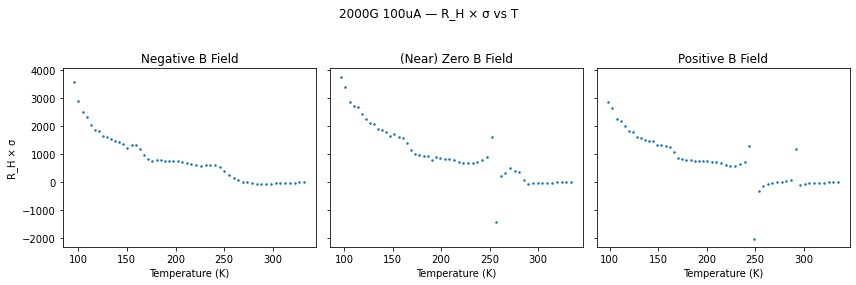

{'label': '2000G100uA.txt',
 'T_mean': 300.3666666666667,
 'rhoxx': 0.0015112499999999968,
 'sigma': 725.1887029880505,
 'hall_coeff': 0.06557493364926802,
 'n': 1.1324300870652679e+20,
 'mu': 47.554201081640144,
 'B_eq': 0.02304615370383781,
 'rho0_for_MR': 0.0022028125000000095}

In [5]:
df_2000G, rt_2000G = analyze_hall_file("2000G100uA.txt", I = 100e-6, plot=False);
analyze_hall_file(df_2000G, label="2000G 100uA", I = 100e-6, plot=True, make_subplots=True);
rt_2000G

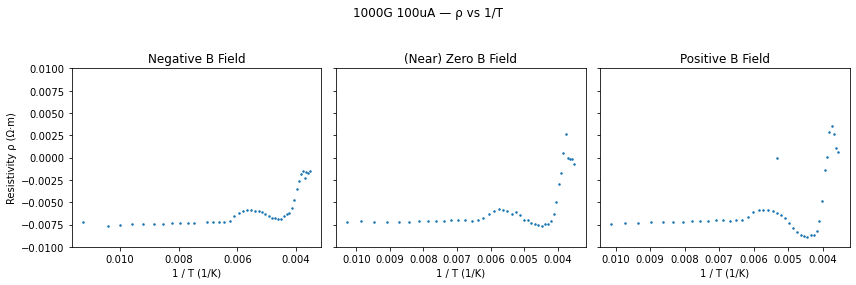

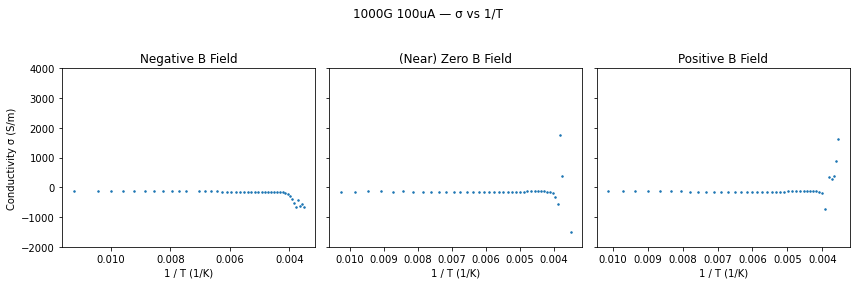

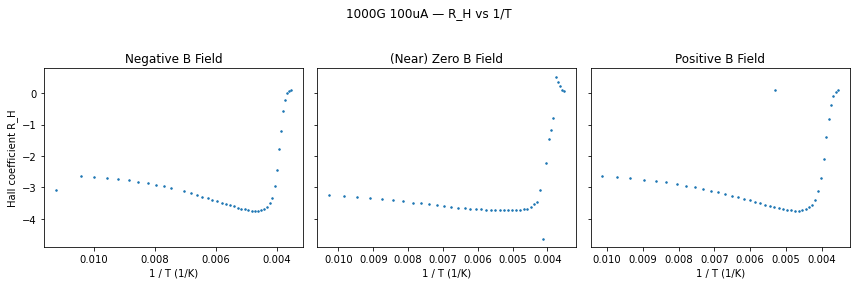

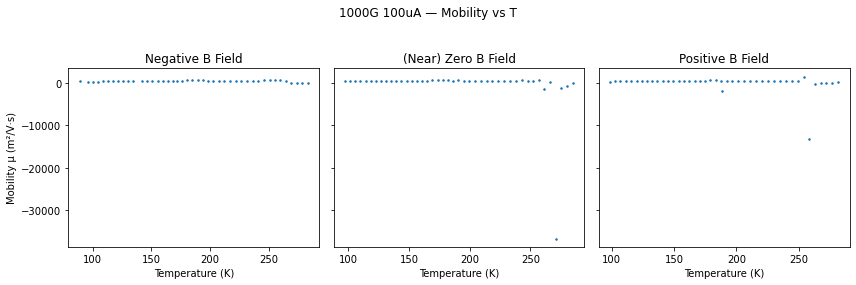

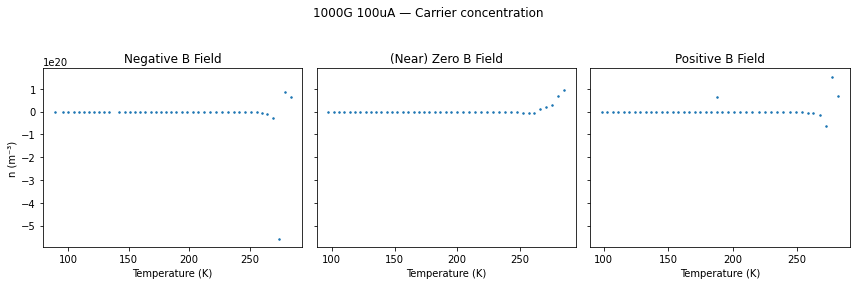

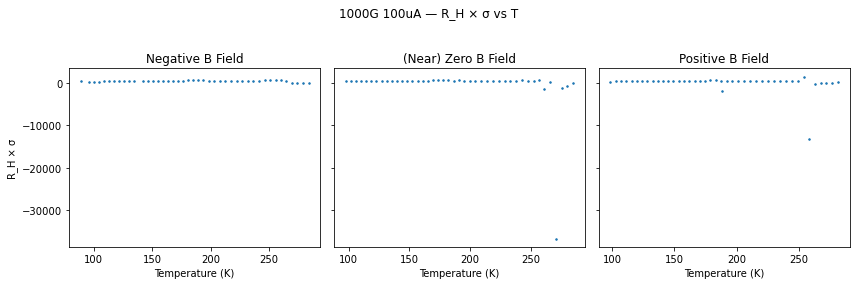

In [6]:
df_1000G, rt_1000G = analyze_hall_file("1000G100uA.txt", I = 100e-6, plot=False);
analyze_hall_file(df_1000G, I = 100e-6, label="1000G 100uA", plot=True, make_subplots=True);

In [10]:
from statsmodels.nonparametric.smoothers_lowess import lowess

def compare_files (file1, file2, ycol, label1, label2):
    df1_, rt1_ = analyze_hall_file(file1, I = 100e-6, plot=False)
    df2_, rt2_ = analyze_hall_file(file2, I = 50e-6, plot=False)
    
    df1_ = df1_.sort_values("inv_T")
    df2_ = df2_.sort_values("inv_T")
    
    plt.figure(figsize=(6,4))
    plt.plot(df1_["inv_T"].to_numpy(), df1_[ycol].to_numpy(), ".", label=label1)
    plt.plot(df2_["inv_T"].to_numpy(), df2_[ycol].to_numpy(), ".", label=label2)
    
    plt.plot(df1_["inv_T"].to_numpy(), df1_[ycol].to_numpy())
    plt.plot(df2_["inv_T"].to_numpy(), df2_[ycol].to_numpy())
    
    #sm1 = lowess((df1_[ycol].to_numpy()), df1_["inv_T"].to_numpy(), frac=0.25, it=3, return_sorted=True)
    #sm2 = lowess((df2_[ycol].to_numpy()), df2_["inv_T"].to_numpy(), frac=0.25, it=3, return_sorted=True)
    #plt.plot(sm1[:,0], sm1[:,1], "-", alpha=0.8)
    #plt.plot(sm2[:,0], sm2[:,1], "-", alpha=0.8)
    plt.xlabel("inv_T")
    plt.ylabel(ycol)
    plt.title(f"{ycol} vs T")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return (df1_, rt1_), (df2_, rt2_)

#compare_files("1000G100uA.txt", "1000G50uA.txt", ycol="hall_coeff", label1="1000 G, 100 µA", label2="1000 G, 50 µA");